# Chicago Urban Context Exploration - Near West Side & Pilsen

This notebook mirrors the spatial and socio-economic analysis performed for the Brás neighborhood in São Paulo. Here, we analyze two comparable neighborhoods in Chicago: **Near West Side** (West Loop/Fulton Market) and **Lower West Side** (Pilsen). Both areas share a strong industrial heritage, dense commercial corridors, and significant transit infrastructure, making them ideal candidates for comparison.

We will explore:
1. Zoning and Territory Distribution
2. Socio-Economic Context (Social Vulnerability)
3. Population Density (Fetched programmatically via Census API)
4. Sidewalk Network Visualization

In [1]:
import os
import geopandas as gpd
import pandas as pd
import shapely.geometry
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
import osmnx as ox
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../analysis/data/'

## 1. Study Area Definition
We define our study areas using `osmnx` to fetch the spatial boundaries of the Near West Side and Lower West Side (Pilsen) directly from OpenStreetMap.

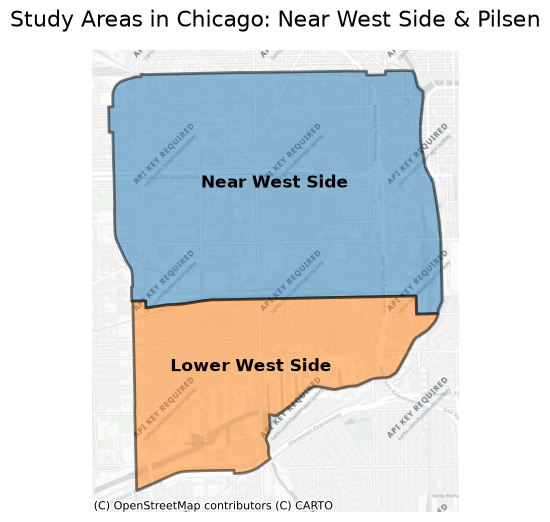

In [2]:
# Fetch boundaries for Near West Side and Pilsen (Lower West Side)
places = ['Near West Side, Chicago, IL, USA', 'Lower West Side, Chicago, IL, USA']
study_areas = ox.geocode_to_gdf(places)
study_areas = study_areas.to_crs(epsg=3857) # Web Mercator for plotting

# Plot the study areas
fig, ax = plt.subplots(figsize=(10, 6))
study_areas.plot(ax=ax, color=['#1f77b4', '#ff7f0e'], alpha=0.5, edgecolor='black', linewidth=2)

# Annotate
for idx, row in study_areas.iterrows():
    ax.annotate(text=row['display_name'].split(',')[0], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                horizontalalignment='center', fontsize=12, weight='bold')

try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
except Exception:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Study Areas in Chicago: Near West Side & Pilsen", fontsize=16)
plt.show()

## 2. Urban Context: Zoning Territory Distribution
We load the current Chicago Zoning Districts dataset to analyze how the territory is distributed. Chicago zoning is prefixed by letters indicating primary use (e.g., 'R' for Residential, 'B' for Business, 'C' for Commercial, 'M' for Manufacturing, 'PMD' for Planned Manufacturing District).

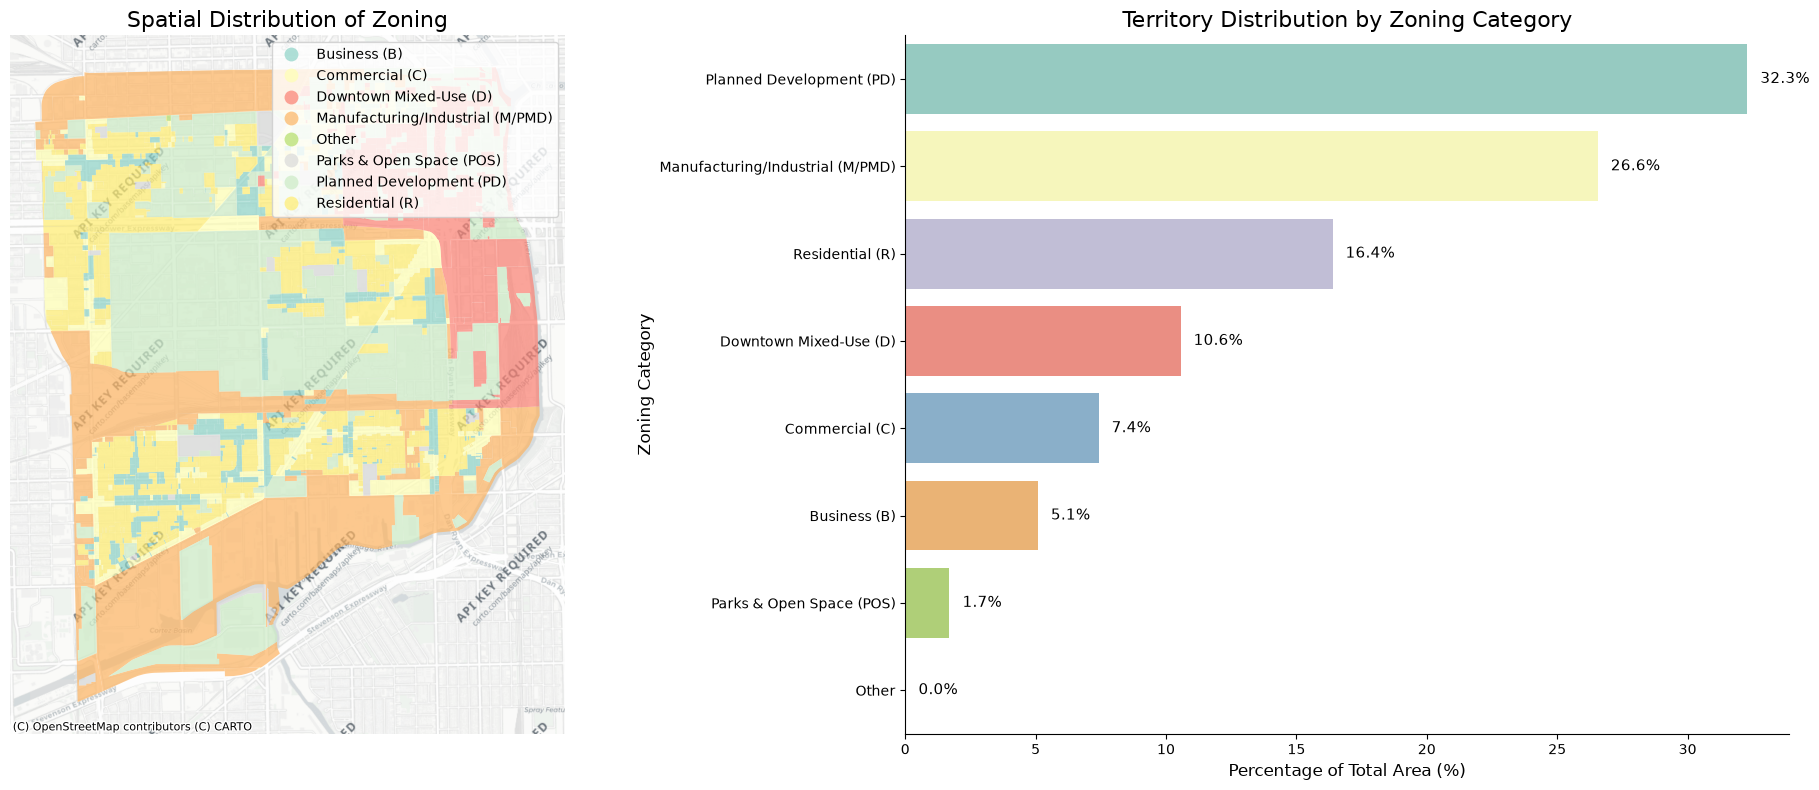

In [3]:
# Load Zoning Data
zoning_gdf = gpd.read_file(os.path.join(DATA_DIR, 'Boundaries_-_Zoning_Districts_(current)_20260831.geojson'))
zoning_gdf = zoning_gdf.to_crs(epsg=3857)

# Categorize zoning based on prefix
def categorize_zoning(zone_class):
    if pd.isna(zone_class): return 'Other'
    if zone_class.startswith('R'): return 'Residential (R)'
    if zone_class.startswith('B'): return 'Business (B)'
    if zone_class.startswith('C'): return 'Commercial (C)'
    if zone_class.startswith('M') or zone_class.startswith('PMD'): return 'Manufacturing/Industrial (M/PMD)'
    if zone_class.startswith('D'): return 'Downtown Mixed-Use (D)'
    if zone_class.startswith('POS'): return 'Parks & Open Space (POS)'
    if zone_class.startswith('PD'): return 'Planned Development (PD)'
    return 'Other'

zoning_gdf['Zoning_Category'] = zoning_gdf['zone_class'].apply(categorize_zoning)

# Clip zoning to study areas
zoning_study = gpd.clip(zoning_gdf, study_areas)
zoning_study['area_sqm'] = zoning_study.geometry.area

# Calculate statistics
zoning_stats = zoning_study.groupby('Zoning_Category')['area_sqm'].sum().reset_index()
total_area = zoning_stats['area_sqm'].sum()
zoning_stats['percentage'] = (zoning_stats['area_sqm'] / total_area) * 100
zoning_stats = zoning_stats.sort_values('percentage', ascending=False)

# Visualization Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 1. Spatial Map of Zoning
zoning_study.plot(ax=ax1, column='Zoning_Category', cmap='Set3', legend=True, alpha=0.7, edgecolor='none')
try:
    cx.add_basemap(ax1, source=cx.providers.CartoDB.Positron)
except Exception:
    cx.add_basemap(ax1, source=cx.providers.OpenStreetMap.Mapnik)
ax1.set_axis_off()
ax1.set_title("Spatial Distribution of Zoning", fontsize=16)

# 2. Bar chart of territorial distribution
sns.barplot(data=zoning_stats, x='percentage', y='Zoning_Category', palette='Set3', ax=ax2)
ax2.set_title('Territory Distribution by Zoning Category', fontsize=16)
ax2.set_xlabel('Percentage of Total Area (%)', fontsize=12)
ax2.set_ylabel('Zoning Category', fontsize=12)

# Annotate bars
for i, p in enumerate(ax2.patches):
    ax2.annotate(f"{p.get_width():.1f}%", 
                (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=11)

sns.despine(ax=ax2)
plt.tight_layout()
plt.show()

### Zoning Analysis: Brás vs. Near West Side & Pilsen
Similar to Brás, the Near West Side and Pilsen exhibit a strong presence of **Manufacturing/Industrial (M/PMD)** zones mixed with **Planned Developments (PD)** and **Downtown Mixed-Use (D)** districts. 
- The Planned Manufacturing Districts (PMDs) in Chicago serve a very similar purpose to the ZDE-1 (Economic Development Zones) in Brás: protecting industrial jobs and logistics from residential gentrification.
- The dense commercial corridors (B and C zones) mirror the ZC (Centrality Zones) of Brás, fostering intense street-level activity.

## 3. Socio-Economic Context: Social Vulnerability
We load the `Socioeconomically_Disadvantaged_Areas` dataset, which highlights regions of hardship. We will analyze the spatial overlap of these areas within our study neighborhoods, drawing a direct parallel to the IPVS high-vulnerability mapping in Brás.

Percentage of territory designated as Socioeconomically Disadvantaged: 19.32%


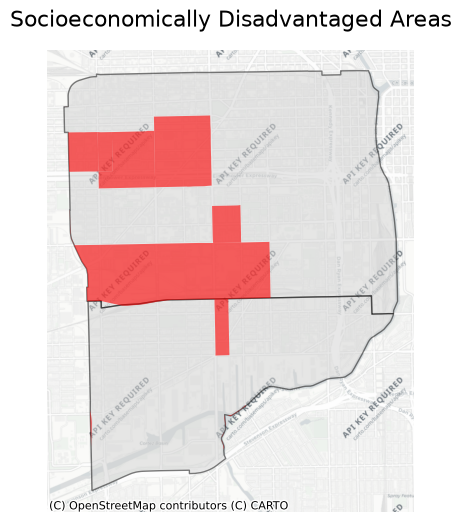

In [4]:
# Load Disadvantaged Areas Data
socio_gdf = gpd.read_file(os.path.join(DATA_DIR, 'Socioeconomically_Disadvantaged_Areas_20260831.geojson'))
socio_gdf = socio_gdf.to_crs(epsg=3857)

# Clip to study areas
socio_study = gpd.clip(socio_gdf, study_areas)
socio_study['area_sqm'] = socio_study.geometry.area

disadvantaged_area = socio_study['area_sqm'].sum()
study_total_area = study_areas.geometry.area.sum()
percentage_disadvantaged = (disadvantaged_area / study_total_area) * 100

print(f"Percentage of territory designated as Socioeconomically Disadvantaged: {percentage_disadvantaged:.2f}%")

# Spatial Map of Vulnerability
fig, ax = plt.subplots(figsize=(10, 6))
study_areas.plot(ax=ax, color='lightgray', alpha=0.5, edgecolor='black', linewidth=1, label='Study Area')
socio_study.plot(ax=ax, color='red', alpha=0.6, label='Disadvantaged Areas')

try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
except Exception:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Socioeconomically Disadvantaged Areas", fontsize=16)
plt.show()

### Social Vulnerability Analysis
The spatial distribution of socioeconomically disadvantaged areas in these Chicago neighborhoods reflects a polarized environment similar to Brás. While the Fulton Market area (northern part of Near West Side) has rapidly gentrified and shed its vulnerability flags, portions of Pilsen and the western edges of the Near West Side remain highly vulnerable.
This polarization—wealthy commercial/residential hubs sitting adjacent to disadvantaged blocks—mirrors the contrast between Brás's commercial wealth and its high-vulnerability *cortiços* (ZEIS-3 zones).

## 4. Population Density (Fetched via Cenpy)
To accurately mirror the demographic analysis, we use the `cenpy` library (which interfaces with the US Census Bureau API) to dynamically fetch the population counts at the Census Tract level for our study areas. We will calculate the density in inhabitants per hectare.

In [5]:
# Install pygris if not present in the environment
import sys
try:
    import pygris
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pygris", "-q"])


Fetching Census Tracts for Cook County via pygris...
Using FIPS code '17' for input 'IL'


Using FIPS code '031' for input 'Cook'


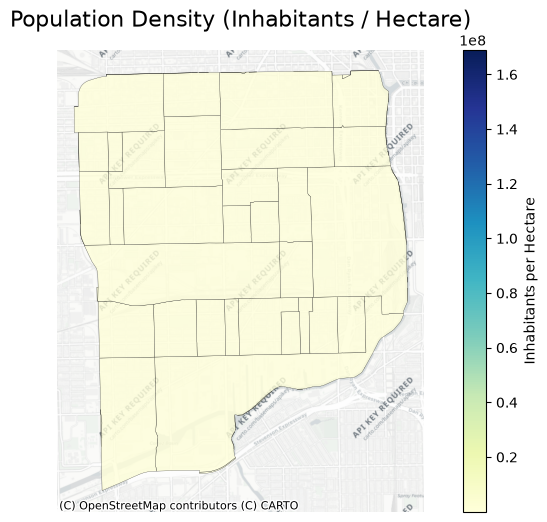

In [6]:
import pygris
import geopandas as gpd
import pandas as pd
import os
import matplotlib.pyplot as plt
import contextily as cx

# Fetch Census Tract boundaries for Cook County, IL using pygris (no API key required)
print("Fetching Census Tracts for Cook County via pygris...")
chicago_census = pygris.tracts(state="IL", county="Cook", year=2019, cache=True)
chicago_census = chicago_census.to_crs(epsg=3857)

# Load population dataset (no API key required)
pop_df = pd.read_csv(os.path.join(DATA_DIR, "cook_county_tracts_pop_2019.csv"))
pop_df["GEOID"] = pop_df["GEOID"].astype(str)
chicago_census["GEOID"] = chicago_census["GEOID"].astype(str)

chicago_census = chicago_census.merge(pop_df[["GEOID", "B01003_001E"]], on="GEOID", how="left")

# Clip census tracts to our study areas
census_study = gpd.clip(chicago_census, study_areas)

# Calculate area in hectares and population density
census_study["area_hectares"] = census_study.geometry.area / 10000
census_study["density_hab_ha"] = census_study["B01003_001E"] / census_study["area_hectares"]

# Plot Population Density
fig, ax = plt.subplots(figsize=(10, 6))
census_study.plot(ax=ax, column="density_hab_ha", cmap="YlGnBu", legend=True, 
                  legend_kwds={"label": "Inhabitants per Hectare"}, alpha=0.8, edgecolor="black", linewidth=0.2)
try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
except Exception:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Population Density (Inhabitants / Hectare)", fontsize=16)
plt.show()


## 5. Sidewalk Network Visualization
Finally, we visualize the physical pedestrian infrastructure using the Chicago Sidewalks dataset. This will allow us to assess the density of the grid.

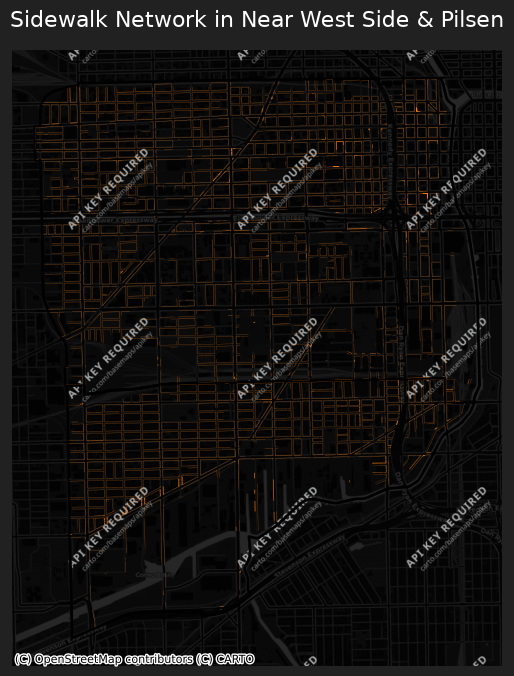

In [7]:
# Load Sidewalks Data
sidewalks_gdf = gpd.read_file(os.path.join(DATA_DIR, 'chicagosidewalks/chicagosidewalks.shp'))
sidewalks_gdf = sidewalks_gdf.to_crs(epsg=3857)

# Clip sidewalks to study areas
sidewalks_study = gpd.clip(sidewalks_gdf, study_areas)

# Plot Sidewalk Network
fig, ax = plt.subplots(figsize=(10, 8))
study_areas.plot(ax=ax, color='none', edgecolor='black', linewidth=2)
sidewalks_study.plot(ax=ax, color='#ff7f0e', linewidth=0.5, alpha=0.8)
try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.DarkMatter)
except Exception:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Sidewalk Network in Near West Side & Pilsen", fontsize=16, color='white')
# Setting background color to black for better contrast
fig.patch.set_facecolor('#212121')
plt.show()

## 6. Synthesis: Comparing Brás to Near West Side & Pilsen
Our comparative analysis reveals striking similarities between Brás (São Paulo) and the Near West Side / Pilsen (Chicago):

1. **Industrial Legacy vs. Transformation:** Both areas use specific zoning (ZDE-1 in Brás, PMD in Chicago) to protect historical manufacturing uses while accommodating high-density residential and commercial transformation along transit corridors.
2. **Polarized Vulnerability:** Both areas exhibit extreme socio-economic duality. Newly developed, low-vulnerability blocks sit directly adjacent to highly vulnerable tracts (analogous to Brás's ZEIS-3 zones and *cortiços*).
3. **Pedestrian Grid:** The dense, historical street grid of these Chicago neighborhoods provides an excellent topological match for Brás, setting the perfect stage for our comparative sidewalk accessibility study.